# Упражнения <a id='tasks'></a>

Необходимо изучить библиотеку [tslearn](https://tslearn.readthedocs.io/en/stable/).

1. Взять выбранные для лабы 14 набор(ы) данных. 

3. Попробовать все методы классификации и регрессии, описанные в блоноте 14 aeon:
    Distance-based 
    Свертки (модели семейства Rocket и Hydra)
    Feature-based
    Deep Learning

    Для каждого подхода обучть не менее 3х разных моделей для классификации и регрессии.
    
     
    

In [32]:
%pip install tslearn

import os
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder
from tslearn.datasets import UCR_UEA_datasets
from tslearn.preprocessing import TimeSeriesScalerMeanVariance

X_train, y_train_raw, X_test, y_test_raw = UCR_UEA_datasets().load_dataset("ArrowHead")

scaler = TimeSeriesScalerMeanVariance()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

le = LabelEncoder()
y_train = le.fit_transform(y_train_raw)
y_test = le.transform(y_test_raw)
y_train_r = y_train.astype(float)
y_test_r = y_test.astype(float)

print("Train:", X_train.shape)
print("Test:", X_test.shape)
print("Classes:", le.classes_)


You should consider upgrading via the 'f:\Education\1course\2trim\RegressionAnalysis\.venv\Scripts\python.exe -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.
Train: (36, 251, 1)
Test: (175, 251, 1)
Classes: [0 1 2]


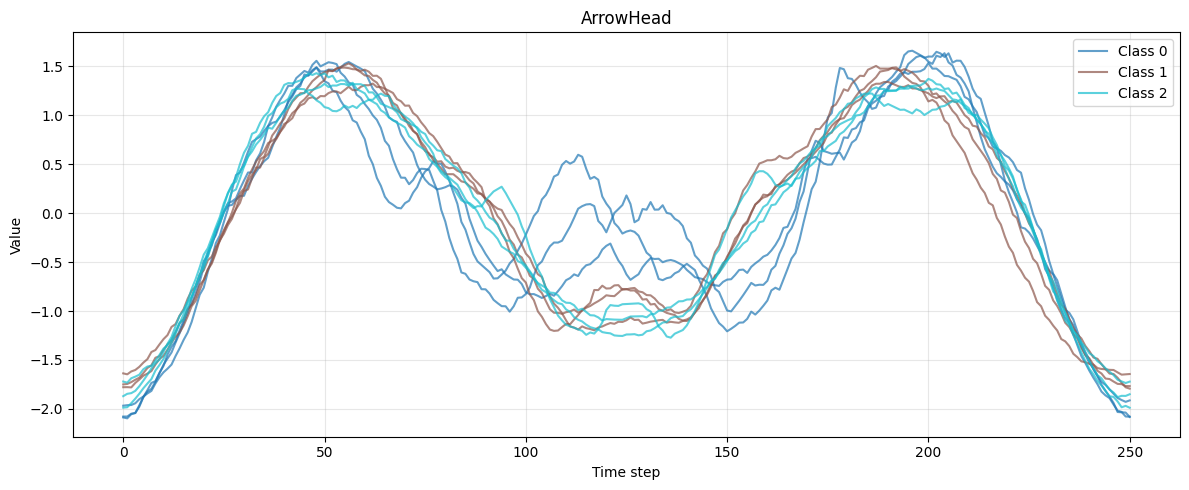

In [33]:
classes = np.unique(y_train)
colors = plt.cm.tab10(np.linspace(0, 1, len(classes)))

plt.figure(figsize=(12, 5))
for idx, cls in enumerate(classes):
    ids = np.where(y_train == cls)[0][:3]
    for j, id_ in enumerate(ids):
        plt.plot(X_train[id_, :, 0], color=colors[idx], alpha=0.7, label=f"Class {le.classes_[cls]}" if j == 0 else "")
plt.title("ArrowHead")
plt.xlabel("Time step")
plt.ylabel("Value")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

classification_results = []
regression_results = []


In [34]:
from tslearn.neighbors import KNeighborsTimeSeriesClassifier, KNeighborsTimeSeriesRegressor
from tslearn.svm import TimeSeriesSVC, TimeSeriesSVR

distance_classifiers = {
    "KNN DTW": KNeighborsTimeSeriesClassifier(n_neighbors=1, metric="dtw"),
    "KNN SoftDTW": KNeighborsTimeSeriesClassifier(n_neighbors=1, metric="softdtw", metric_params={"gamma": 0.1}),
    "SVC GAK": TimeSeriesSVC(kernel="gak", gamma="auto"),
}

distance_regressors = {
    "KNNR DTW": KNeighborsTimeSeriesRegressor(n_neighbors=1, metric="dtw"),
    "KNNR Euclidean": KNeighborsTimeSeriesRegressor(n_neighbors=3, metric="euclidean"),
    "SVR GAK": TimeSeriesSVR(kernel="gak", gamma="auto"),
}

for name, model in distance_classifiers.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    score = accuracy_score(y_test, preds)
    classification_results.append({"type": "Distance-based", "model": name, "score": score})
    print(name, score)

for name, model in distance_regressors.items():
    model.fit(X_train, y_train_r)
    preds = model.predict(X_test)
    score = mean_squared_error(y_test_r, preds)
    regression_results.append({"type": "Distance-based", "model": name, "score": score})
    print(name, score)


KNN DTW 0.7028571428571428
KNN SoftDTW 0.7257142857142858
SVC GAK 0.5657142857142857
KNNR DTW 0.4857142857142857
KNNR Euclidean 0.3352380952380953
SVR GAK 0.3532658384560284


In [ ]:
import numpy as np
from tslearn.clustering import TimeSeriesKMeans, KShape
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.linear_model import RidgeClassifier, Ridge
from sklearn.metrics import accuracy_score, mean_squared_error

cluster_models = {
    "KMeans Euclidean": TimeSeriesKMeans(n_clusters=6, metric="euclidean", random_state=42),
    "KMeans DTW": TimeSeriesKMeans(n_clusters=6, metric="dtw", random_state=42),
    "KShape": KShape(n_clusters=6, random_state=42),
}

cluster_features_train = []
cluster_features_test = []

for name, model in cluster_models.items():
    model.fit(X_train)
    
    if name == "KShape":
        cluster_train = model.predict(X_train)
        cluster_test = model.predict(X_test)
        cluster_features_train.append(np.expand_dims(cluster_train, axis=1)) 
        cluster_features_test.append(np.expand_dims(cluster_test, axis=1))
    else:
        cluster_features_train.append(model.transform(X_train))
        cluster_features_test.append(model.transform(X_test))

X_train_cluster = np.hstack(cluster_features_train)
X_test_cluster = np.hstack(cluster_features_test)

cluster_classifiers = {
    "Cluster RF": RandomForestClassifier(n_estimators=50, random_state=42),
    "Cluster GB": GradientBoostingClassifier(n_estimators=50, random_state=42),
    "Cluster Ridge": RidgeClassifier(),
}

cluster_regressors = {
    "Cluster RF": RandomForestRegressor(n_estimators=50, random_state=42),
    "Cluster GB": GradientBoostingRegressor(n_estimators=50, random_state=42),
    "Cluster Ridge": Ridge(),
}

classification_results = []
regression_results = []

for name, model in cluster_classifiers.items():
    model.fit(X_train_cluster, y_train)
    preds = model.predict(X_test_cluster)
    score = accuracy_score(y_test, preds)
    classification_results.append({"type": "Cluster-based", "model": name, "score": score})
    print(name, score)

for name, model in cluster_regressors.items():
    model.fit(X_train_cluster, y_train_r)
    preds = model.predict(X_test_cluster)
    score = mean_squared_error(y_test_r, preds)
    regression_results.append({"type": "Cluster-based", "model": name, "score": score})
    print(name, score)

Cluster RF 0.5714285714285714
Cluster GB 0.5085714285714286
Cluster Ridge 0.6
Cluster RF 0.5747611428571429
Cluster GB 0.6889763940454435
Cluster Ridge 1.1219773183151005


In [36]:
from tslearn.piecewise import PiecewiseAggregateApproximation, SymbolicAggregateApproximation, OneD_SymbolicAggregateApproximation
from sklearn.svm import SVC, SVR

def flatten_ts(X):
    return X.reshape((X.shape[0], -1))

paa = PiecewiseAggregateApproximation(n_segments=24)
sax = SymbolicAggregateApproximation(n_segments=24, alphabet_size_avg=8)
one_d_sax = OneD_SymbolicAggregateApproximation(n_segments=24, alphabet_size_avg=8, alphabet_size_slope=8)

X_train_paa = flatten_ts(paa.fit_transform(X_train))
X_test_paa = flatten_ts(paa.transform(X_test))
X_train_sax = flatten_ts(sax.fit_transform(X_train))
X_test_sax = flatten_ts(sax.transform(X_test))
X_train_one_d_sax = flatten_ts(one_d_sax.fit_transform(X_train))
X_test_one_d_sax = flatten_ts(one_d_sax.transform(X_test))

feature_sets = {
    "PAA": (X_train_paa, X_test_paa),
    "SAX": (X_train_sax, X_test_sax),
    "1d-SAX": (X_train_one_d_sax, X_test_one_d_sax),
}

for name, (X_tr, X_te) in feature_sets.items():
    clf = RandomForestClassifier(n_estimators=50, random_state=42)
    clf.fit(X_tr, y_train)
    preds = clf.predict(X_te)
    score = accuracy_score(y_test, preds)
    classification_results.append({"type": "Feature-based", "model": name, "score": score})
    print(name, score)

for name, (X_tr, X_te) in feature_sets.items():
    rgs = RandomForestRegressor(n_estimators=50, random_state=42)
    rgs.fit(X_tr, y_train_r)
    preds = rgs.predict(X_te)
    score = mean_squared_error(y_test_r, preds)
    regression_results.append({"type": "Feature-based", "model": name, "score": score})
    print(name, score)


PAA 0.6228571428571429
SAX 0.7257142857142858
1d-SAX 0.68
PAA 0.395088
SAX 0.39600457142857143
1d-SAX 0.373136


In [37]:
from tslearn.neural_network import TimeSeriesMLPClassifier, TimeSeriesMLPRegressor

mlp_classifiers = {
    "MLP 032": TimeSeriesMLPClassifier(hidden_layer_sizes=(32,), max_iter=200, random_state=42),
    "MLP 064": TimeSeriesMLPClassifier(hidden_layer_sizes=(64,), max_iter=200, random_state=42),
    "MLP 064x032": TimeSeriesMLPClassifier(hidden_layer_sizes=(64, 32), max_iter=200, random_state=42),
}

mlp_regressors = {
    "MLP 032": TimeSeriesMLPRegressor(hidden_layer_sizes=(32,), max_iter=200, random_state=42),
    "MLP 064": TimeSeriesMLPRegressor(hidden_layer_sizes=(64,), max_iter=200, random_state=42),
    "MLP 064x032": TimeSeriesMLPRegressor(hidden_layer_sizes=(64, 32), max_iter=200, random_state=42),
}

for name, model in mlp_classifiers.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    score = accuracy_score(y_test, preds)
    classification_results.append({"type": "Neural-network", "model": name, "score": score})
    print(name, score)

for name, model in mlp_regressors.items():
    model.fit(X_train, y_train_r)
    preds = model.predict(X_test)
    score = mean_squared_error(y_test_r, preds)
    regression_results.append({"type": "Neural-network", "model": name, "score": score})
    print(name, score)


f:\Education\1course\2trim\RegressionAnalysis\.venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
f:\Education\1course\2trim\RegressionAnalysis\.venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLP 032 0.8057142857142857
MLP 064 0.7942857142857143


f:\Education\1course\2trim\RegressionAnalysis\.venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
f:\Education\1course\2trim\RegressionAnalysis\.venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLP 064x032 0.7828571428571428
MLP 032 0.6739283340889709
MLP 064 0.5802144805396114
MLP 064x032 0.5405463738516015


f:\Education\1course\2trim\RegressionAnalysis\.venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


             type          model     score
0  Neural-network        MLP 032  0.805714
1  Neural-network        MLP 064  0.794286
2  Neural-network    MLP 064x032  0.782857
3   Feature-based            SAX  0.725714
4   Feature-based         1d-SAX  0.680000
5   Feature-based            PAA  0.622857
6   Cluster-based  Cluster Ridge  0.600000
7   Cluster-based     Cluster RF  0.571429
8   Cluster-based     Cluster GB  0.508571
             type          model     score
0   Feature-based         1d-SAX  0.373136
1   Feature-based            PAA  0.395088
2   Feature-based            SAX  0.396005
3  Neural-network    MLP 064x032  0.540546
4   Cluster-based     Cluster RF  0.574761
5  Neural-network        MLP 064  0.580214
6  Neural-network        MLP 032  0.673928
7   Cluster-based     Cluster GB  0.688976
8   Cluster-based  Cluster Ridge  1.121977


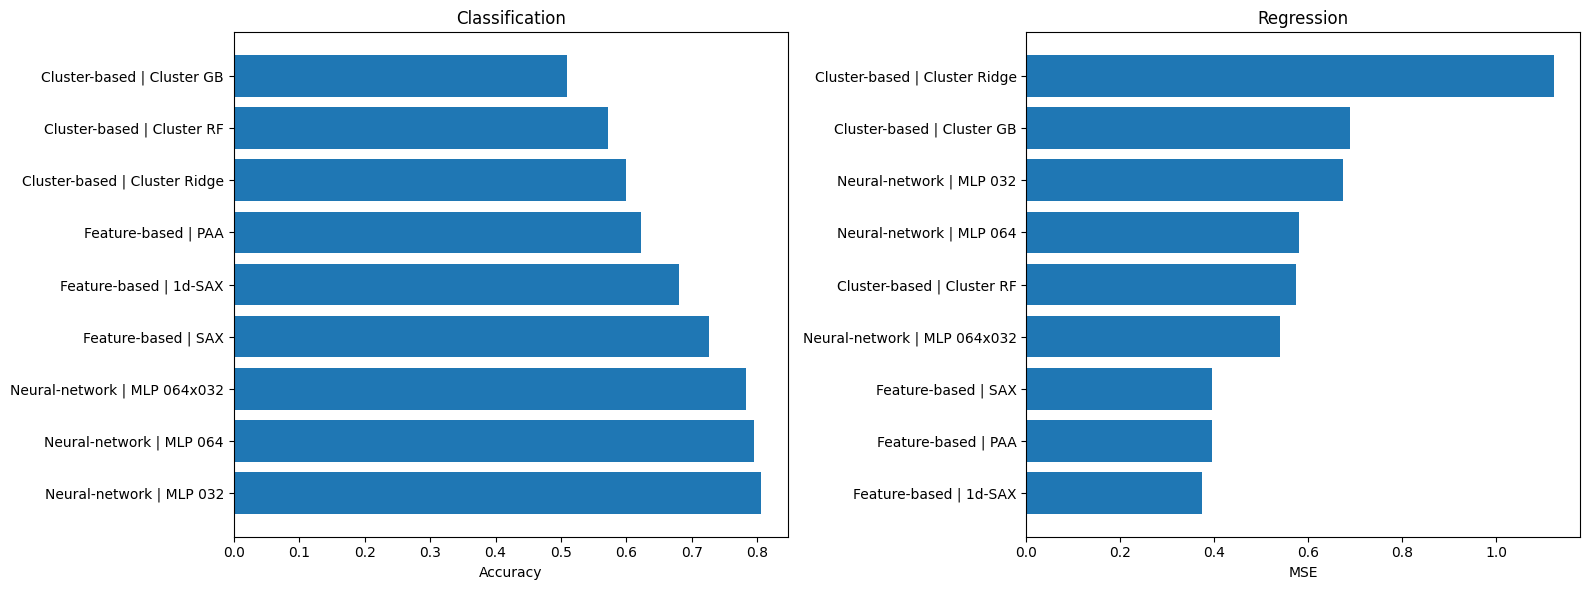

In [38]:
classification_results = pd.DataFrame(classification_results).sort_values("score", ascending=False).reset_index(drop=True)
regression_results = pd.DataFrame(regression_results).sort_values("score").reset_index(drop=True)

print(classification_results)
print(regression_results)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))
ax[0].barh(classification_results["type"] + " | " + classification_results["model"], classification_results["score"])
ax[0].set_title("Classification")
ax[0].set_xlabel("Accuracy")
ax[1].barh(regression_results["type"] + " | " + regression_results["model"], regression_results["score"])
ax[1].set_title("Regression")
ax[1].set_xlabel("MSE")
plt.tight_layout()
plt.show()
